In [1]:
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt

from src.nnet.torchBaselineModel import BaselineModel
from torchinfo import summary
from src.utils.my_utils import augment_image

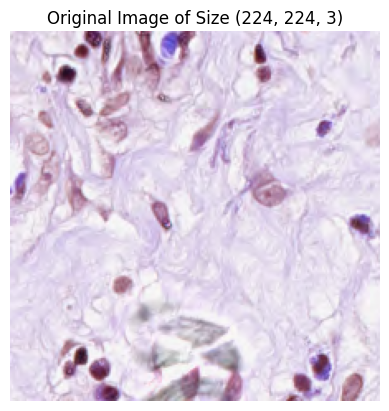

In [2]:
img = cv2.imread(r'C:\Users\jluo1\Documents\repos\histopathology_classification\data\HMU-GC-HE-30K\all_image\MUS\MUS_6.png')
img = img.astype('float32') / 255.0
plt.imshow(img)
plt.axis('off')
plt.title(f'Original Image of Size {img.shape}')
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08632901..1.265308].


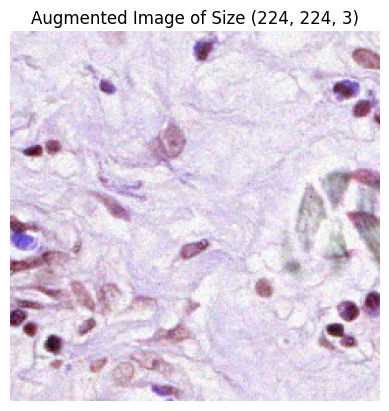

In [3]:
augmented_img = augment_image(img)
plt.imshow(augmented_img)
plt.axis('off')
plt.title(f'Augmented Image of Size {img.shape}')
plt.show()

In [4]:
model = BaselineModel(num_classes=8, num_channels=3)
input_size = (1, 3, 224, 224)
summary(model, input_size=input_size)

Layer (type:depth-idx)                        Output Shape              Param #
BaselineModel                                 [1, 8]                    --
├─Sequential: 1-1                             [1, 32, 74, 74]           --
│    └─Conv2d: 2-1                            [1, 32, 224, 224]         896
│    └─Conv2d: 2-2                            [1, 32, 224, 224]         9,248
│    └─MaxPool2d: 2-3                         [1, 32, 74, 74]           --
│    └─ReLU: 2-4                              [1, 32, 74, 74]           --
├─Sequential: 1-2                             [1, 64, 24, 24]           --
│    └─Conv2d: 2-5                            [1, 64, 74, 74]           18,496
│    └─Conv2d: 2-6                            [1, 64, 74, 74]           36,928
│    └─CBAMBlock: 2-7                         [1, 64, 74, 74]           --
│    │    └─ChannelAttention: 3-1             [1, 64, 74, 74]           1,096
│    │    └─SpatialAttention: 3-2             [1, 64, 74, 74]           51
│    